# NIRSPEC 6927 Candidate Selection

In [1]:
from astropy.table import Table
from astropy.io import fits
from astropy import wcs
import regions
import pylab as pl
from astroquery.svo_fps import SvoFps
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy import coordinates
from dust_extinction.averages import RRP89_MWGC, CT06_MWGC, F11_MWGC

In [2]:
# specially created from intermediate products on 2026-07-14 (2027 was a typo...)
# "final final" products should be later this week, but need this _now_

tb = Table.read('/Users/adam/Dropbox/brick2221/brick_crossband_m7_merge_20260714.fits')
wholebrickreg = regions.Regions.read('/Users/adam//work/brick/jwst/brick-jwst-2221/regions_/dark_innerbrick_polygon.reg')[0]

tb_6927_default = Table.read('/Users/adam/Dropbox/brick2221/nirspec6927/MPT_sourcelist.v17.txt', format='ascii')

jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')


# for col in [x for x in tb.colnames if 'flux' in x and 'err' not in x]:
#     pixelscale = (0.031*u.arcsec)**2 if int(col[1:4]) < 250 else (0.063*u.arcsec)**2
#     flux_jy = (tb[col] * u.MJy/u.sr * pixelscale).to(u.Jy)
#     eflux_jy = (tb[col+"_err"] * u.MJy/u.sr * pixelscale).to(u.Jy)
#     filtername = f'JWST/NIRCam.{col[:5].upper()}'
#     zeropoint = u.Quantity(jfilts.loc[filtername]['ZeroPoint'], u.Jy)
#     vegamag = -2.5 * np.log10(flux_jy / zeropoint) * u.mag
#     mag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux_jy) * u.mag
#     tb[f'mag_{col[:5]}'] = vegamag
#     tb[f'mag_{col[:5]}'].meta = {'system': 'Vega mag'}
#     tb[f'emag_{col[:5]}'] = mag_err
#     tb[f'emag_{col[:5]}'].meta = {'system': 'eVega mag'}
basetable = tb

tb['skycoord_ref'] = crd = coordinates.SkyCoord(tb['ra'], tb['dec'], unit=(u.deg, u.deg), frame='icrs')

fh = fits.open('/Users/adam/Dropbox/brick2221/20240802_FITS/jw02221-o001_t001_nircam_clear-f410m-merged_i2d.fits')
ww = wcs.WCS(fh['SCI'].header)


av182410 = (basetable['f182m_mag_vega'] - basetable['f410m_mag_vega']) / (CT06_MWGC()(1.82*u.um) - CT06_MWGC()(4.10*u.um))
av182212 = (basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) / (CT06_MWGC()(1.82*u.um) - CT06_MWGC()(2.12*u.um))

Set DATE-AVG to '2022-08-28T03:05:32.473' from MJD-AVG.
Set DATE-END to '2022-08-28T03:34:03.557' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -20.661125 from OBSGEO-[XYZ].
Set OBSGEO-H to 1526408297.850 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [30]:
for col in tb.colnames:
    if col[5:] == '_mag_ab':
        dmag = tb[col] - tb[col[:-2]+"vega"]
        dmag = dmag[np.isfinite(dmag)]
        print(col[:5], np.nanmedian(dmag), np.nanstd(dmag))

f212n 1.8270113541527753 1.90611112297366e-15
f115w 0.7948161039487438 2.851589546928562e-15
f182m 1.5829310928148175 2.0702959994877035e-15
f187n 1.6492895678548791 1.8159697271089887e-15
f200w 1.7013229789546394 3.5571686748357e-15
f356w 2.8160048811205556 1.920226605433851e-15
f405n 3.1102346531507017 1.8721788714086316e-15
f410m 3.1009314459889765 2.022376323444819e-15
f444w 3.2373524250764483 2.5201129618847426e-15
f466n 3.4049178427084534 1.945338566522366e-15


In [24]:
tb.colnames

['ra',
 'dec',
 'f212n_flux',
 'f212n_flux_err',
 'f212n_qfit',
 'f212n_cfit',
 'f212n_flux_init',
 'f212n_flags',
 'f212n_local_bkg',
 'f212n_group_size',
 'f212n_dra',
 'f212n_ddec',
 'f212n_std_ra',
 'f212n_std_dec',
 'f212n_nmatch',
 'f212n_nmatch_good',
 'f212n_flux_err_prop',
 'f212n_is_saturated',
 'f212n_replaced_saturated',
 'f212n_iter_found',
 'f212n_prominence',
 'f212n_peak_sb',
 'f212n_flux_jy',
 'f212n_eflux_jy',
 'f212n_mag_vega',
 'f212n_emag_vega',
 'f212n_mag_ab',
 'f212n_emag_ab',
 'f212n_ra',
 'f212n_dec',
 'f212n_detected',
 'f115w_flux',
 'f115w_flux_err',
 'f115w_qfit',
 'f115w_cfit',
 'f115w_flux_init',
 'f115w_flags',
 'f115w_local_bkg',
 'f115w_group_size',
 'f115w_dra',
 'f115w_ddec',
 'f115w_std_ra',
 'f115w_std_dec',
 'f115w_nmatch',
 'f115w_nmatch_good',
 'f115w_flux_err_prop',
 'f115w_satstar_match_sep',
 'f115w_is_saturated',
 'f115w_replaced_saturated',
 'f115w_iter_found',
 'f115w_prominence',
 'f115w_peak_sb',
 'f115w_local_emission_snr',
 'f115w_sky

In [3]:
len(tb_6927_default)

7566

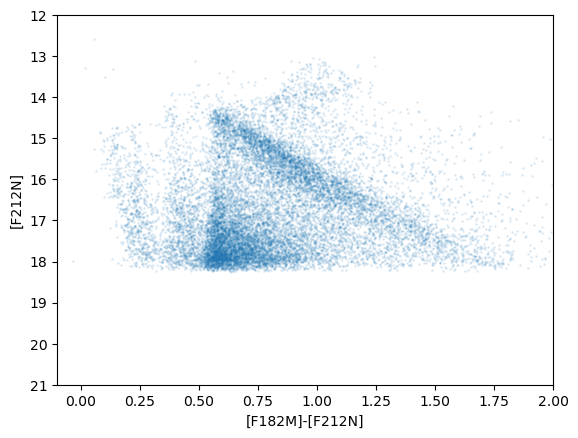

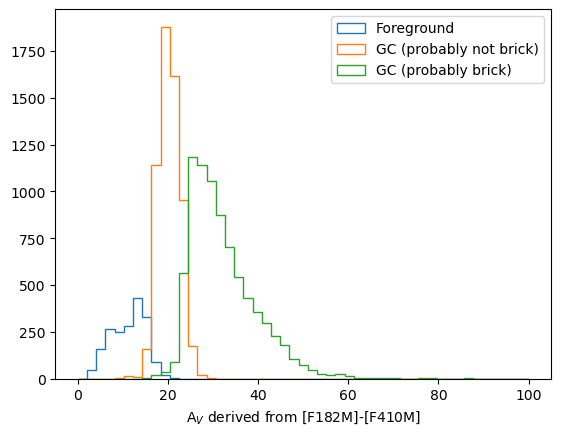

In [4]:
notbad = (
          (basetable['f212n_emag_vega'] < 0.05) &
          (basetable['f410m_emag_vega'] < 0.05) &
          (basetable['f182m_emag_vega'] < 0.05) &
          (basetable['f212n_nmatch_good'] > 4) &
          (basetable['f182m_nmatch_good'] > 4) &
          (basetable['f410m_nmatch_good'] > 4) &
            (basetable['f212n_qfit'] < 0.4) &
            (basetable['f182m_qfit'] < 0.4) &
            (basetable['f410m_qfit'] < 0.4) 
)

bright = ((basetable['f212n_mag_vega'] > 14) &
          (basetable['f212n_mag_vega'] < 18) & notbad)
          

pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[notbad], basetable['f212n_mag_vega'][notbad], s=1, alpha=0.1)
incl = wholebrickreg.contains(basetable['skycoord_ref'], ww) & notbad
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[incl], basetable['f212n_mag_vega'][incl], s=1, alpha=0.1)
#pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright], basetable['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 2, 21, 12]);
pl.xlabel("[F182M]-[F212N]")
pl.ylabel("[F212N]");

pl.figure()
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) < 0.5)], bins=np.linspace(0, 100),
        label='Foreground', histtype='step', density=False);
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) < 0.75) & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) > 0.5)], bins=np.linspace(0, 100),
        label='GC (probably not brick)', histtype='step', density=False);
pl.hist(av182410[bright & ((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega']) > 0.75)], bins=np.linspace(0, 100),
        label='GC (probably brick)', histtype='step', density=False);
pl.legend(loc='best');
pl.xlabel("A$_V$ derived from [F182M]-[F410M]");


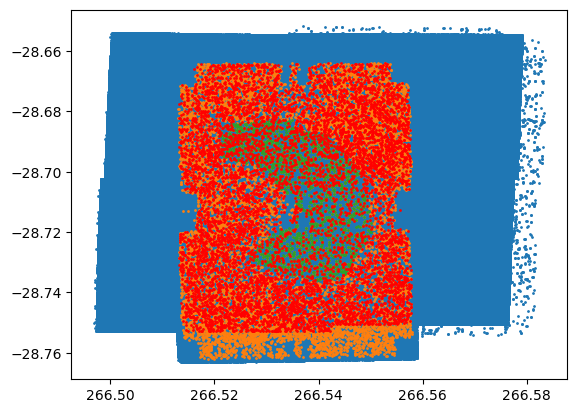

In [5]:
pl.scatter(tb['skycoord_ref'].ra, tb['skycoord_ref'].dec, s=1)
pl.scatter(tb['skycoord_ref'].ra[bright], tb['skycoord_ref'].dec[bright], s=1)
pl.scatter(tb['skycoord_ref'].ra[incl], tb['skycoord_ref'].dec[incl], s=1)
pl.scatter(tb_6927_default['RA'], tb_6927_default['DEC'], s=1, c='r')

### Find mutual matches between 6927-candidate-list-from-2025 and new catalog

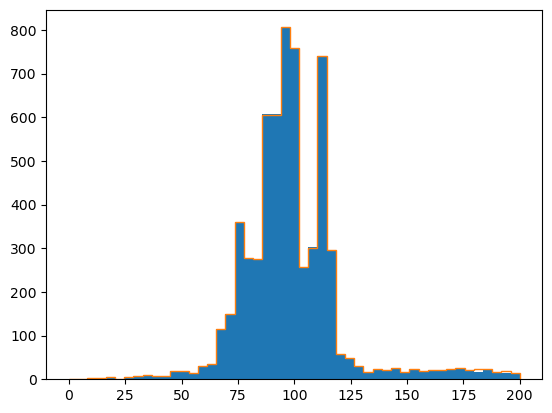

In [6]:
crd6927 = SkyCoord(tb_6927_default['RA'], tb_6927_default['DEC'], unit=(u.deg, u.deg), frame='icrs')
#i1, i2, sep, _ = search_around_sky(crd6927, crd[notbad], 0.4*u.arcsec)
matches, sep, _ = crd6927.match_to_catalog_sky(crd[bright], nthneighbor=1)
reverse_matches, reverse_sep, _ = crd[bright].match_to_catalog_sky(crd6927, nthneighbor=1)
pl.hist(sep.to(u.marcsec), bins=np.linspace(0., 0.2)*u.arcsec)
pl.hist(reverse_sep.to(u.marcsec), histtype='step', bins=np.linspace(0, 0.2)*u.arcsec);

## re-match them and check that the matches stay the same (100 marcs is big enough to make mismatches possible)

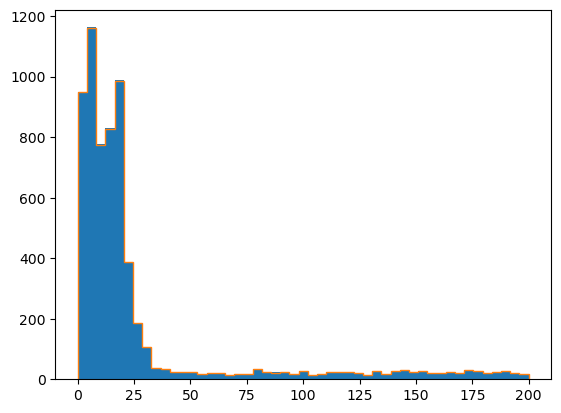

In [7]:
dra_crd = (crd6927.ra - crd[bright].ra[matches]).to(u.deg).value
ddec = (crd6927.dec - crd[bright].dec[matches]).to(u.deg).value
crd6927_fixed = SkyCoord(tb_6927_default['RA'] - np.median(dra_crd), tb_6927_default['DEC'] - np.median(ddec),
                         unit=(u.deg, u.deg), frame='icrs')

matches, sep, _ = crd6927_fixed.match_to_catalog_sky(crd[bright], nthneighbor=1)
reverse_matches, reverse_sep, _ = crd[bright].match_to_catalog_sky(crd6927_fixed, nthneighbor=1)
pl.hist(sep.to(u.marcsec), bins=np.linspace(0., 0.2)*u.arcsec)
pl.hist(reverse_sep.to(u.marcsec), histtype='step', bins=np.linspace(0, 0.2)*u.arcsec);

## Preserve the WEIGHTS from Matt's v17 catalog

In [8]:
tb['WEIGHT'] = 0
tb['WEIGHT'][bright] =  tb_6927_default['WEIGHT'][reverse_matches]

In [9]:
len(tb[bright])

15948

# How many F115W stars do we include that can be used as guidestars?

In [10]:
(tb[bright]['f115w_emag_vega'] < 0.1).sum()

np.int64(12356)

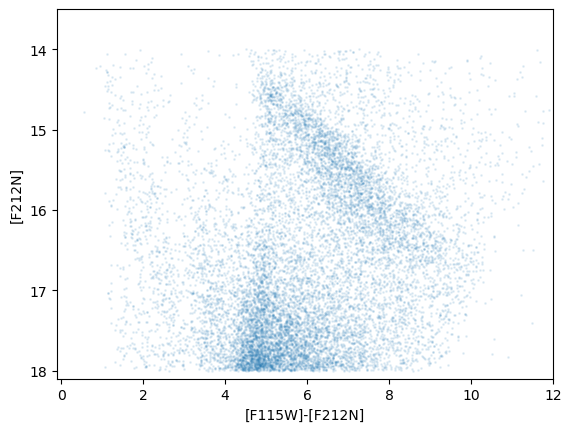

In [11]:
pl.scatter((tb['f115w_mag_vega'] - tb['f212n_mag_vega'])[bright], tb['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 12, 18.1, 13.5]);
pl.xlabel("[F115W]-[F212N]")
pl.ylabel("[F212N]");

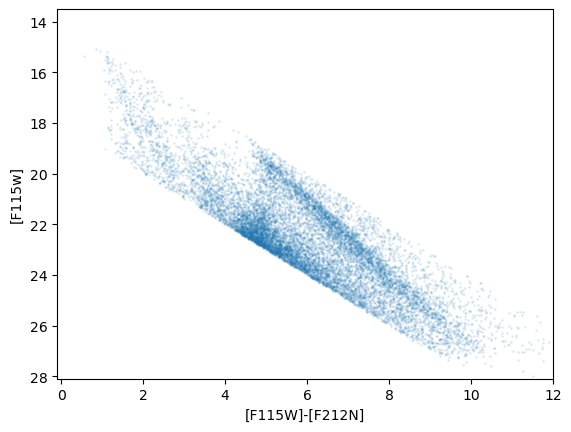

In [12]:
pl.scatter((tb['f115w_mag_vega'] - tb['f212n_mag_vega'])[bright], tb['f115w_mag_vega'][bright], s=1, alpha=0.1)
pl.axis([-0.1, 12, 28.1, 13.5]);
pl.xlabel("[F115W]-[F212N]")
pl.ylabel("[F115w]");

In [13]:
tb[bright].write('/Users/adam/Dropbox/brick2221/20260714_m7_merged_catalog_NIRSPEC6927_candidates.fits', overwrite=True)

## Compare to old candidate list

In [14]:
tb2024 = Table.read('/Users/adam/Dropbox/brick2221//20240802_FITS/basic_merged_indivexp_photometry_tables_merged_nirspeccand.fits')
len(tb2024)

12390

In [15]:
wholebrickreg.contains(tb2024['skycoord_ref'], ww).sum()

np.int64(1622)

In [16]:
red_182410 = ((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f410m']) > 0.75)
red_182410.sum()

np.int64(12037)

In [17]:
red_182212 = ((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f212n']) > 0.75)
red_182212.sum()

np.int64(6621)

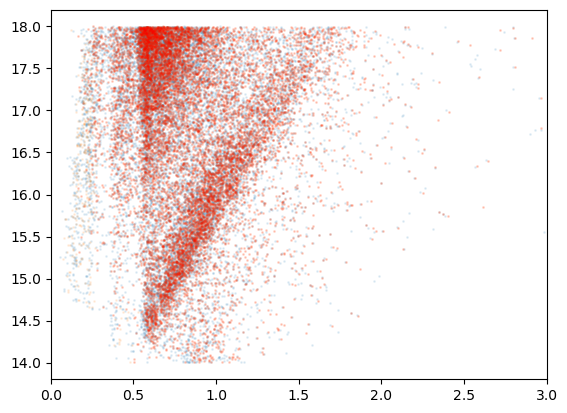

In [18]:
pl.scatter((basetable['f182m_mag_vega'] - basetable['f212n_mag_vega'])[bright], basetable['f212n_mag_vega'][bright], s=1, alpha=0.1)
pl.scatter((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f212n']), tb2024['mag_ab_f212n'], s=1, alpha=0.1)
pl.scatter((tb2024['mag_ab_f182m'] - tb2024['mag_ab_f212n'])[red_182410], tb2024['mag_ab_f212n'][red_182410], s=1, alpha=0.1, c='r')
pl.xlim(0,3);

## Verify pointing against VIRAC tied to gaia

In [19]:
def quiver(c1, c2, figsize=(5,10), csys=None, max_sep=0.1*u.arcsec, alpha=0.5, **kwargs):
    matches, sep, _ = c1.match_to_catalog_sky(c2, nthneighbor=1)
    reverse_matches, reverse_sep, _ = c2.match_to_catalog_sky(c1, nthneighbor=1)
    #mutual_reverse_matches = (matches[reverse_matches] == np.arange(len(reverse_matches)))
    #mutual_matches = (reverse_matches[matches] == np.arange(len(matches)))

    # Keep c1[i] only when its selected c2 source points back to c1[i].
    mutual_mask = (
        reverse_matches[matches]
        == np.arange(len(c1))
    )


    
    keep = sep.to(u.marcsec)[mutual_mask] < max_sep

    pl.hist(sep.to(u.marcsec)[mutual_mask][keep])

    
    c1_mutual = c1[mutual_mask][keep]

    # Critical: this preserves pairwise alignment with c1_mutual.
    c2_mutual = c2[matches[mutual_mask]][keep]
    
    pl.figure(figsize=figsize)
    if csys == 'gal':
        pl.quiver(c1_mutual.galactic.l.value,
              c1_mutual.galactic.b.value,
               (c1_mutual.galactic.l - c2_mutual.galactic.l).value,
               (c1_mutual.galactic.b - c2_mutual.galactic.b).value,
           alpha=alpha, **kwargs);    
    else:
        pl.quiver(c1_mutual.ra.value,
                  c1_mutual.dec.value,
                   (c1_mutual.ra - c2_mutual.ra).value,
                   (c1_mutual.dec - c2_mutual.dec).value,
               alpha=alpha, **kwargs);    

    print(np.nanmedian(c1_mutual.ra - c2_mutual.ra).to(u.marcsec),
          np.nanmedian(c1_mutual.dec - c2_mutual.dec).to(u.marcsec))

In [20]:
virac = Table.read('/Users/adam/Dropbox/brick2221/gaia_virac2_refcat_epoch2022.70.fits')

-6.26215 marcsec -8.95392 marcsec


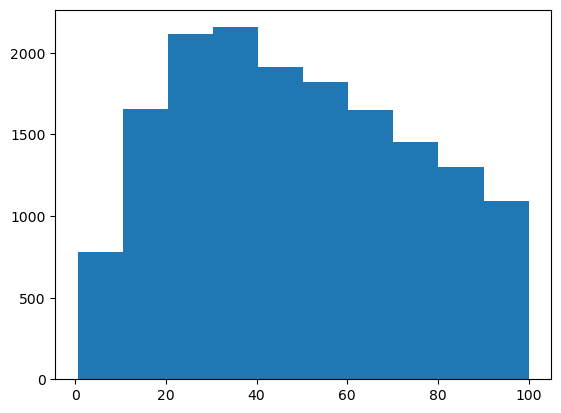

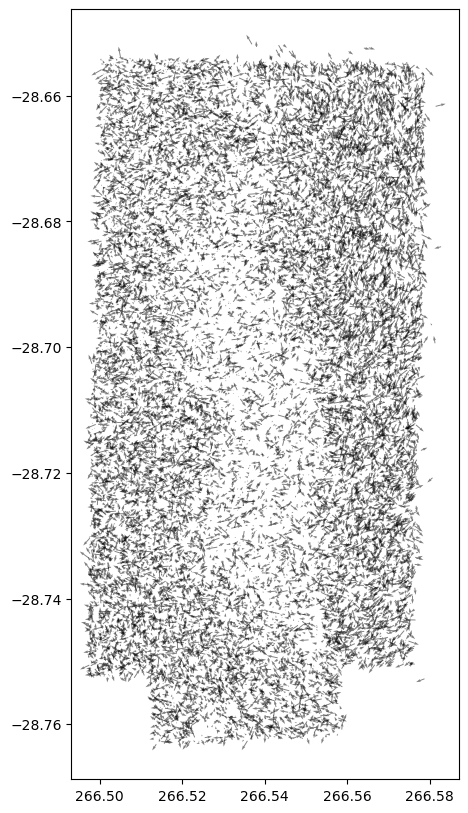

In [21]:
quiver(virac['skycoord'], crd, scale=0.001)

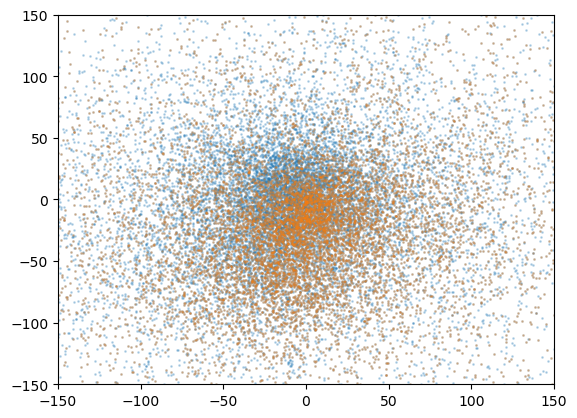

In [22]:
c1 = virac['skycoord']
c2 = crd
matches, sep, _ = c1.match_to_catalog_sky(c2, nthneighbor=1)
reverse_matches, reverse_sep, _ = c2.match_to_catalog_sky(c1, nthneighbor=1)
# Keep c1[i] only when its selected c2 source points back to c1[i].
mutual_mask = (
    reverse_matches[matches]
    == np.arange(len(c1))
)
max_sep = 0.3*u.arcsec
keep = sep.to(u.marcsec)[mutual_mask] < max_sep
c1_mutual = c1[mutual_mask][keep]
# Critical: this preserves pairwise alignment with c1_mutual.
c2_mutual = c2[matches[mutual_mask]][keep]


pl.scatter((c1_mutual.ra - c2_mutual.ra).to(u.marcsec),
           (c1_mutual.dec - c2_mutual.dec).to(u.marcsec),
           s=1, alpha=0.25);
top = c1_mutual.dec > np.median(c1_mutual.dec)
pl.scatter((c1_mutual.ra - c2_mutual.ra)[top].to(u.marcsec),
           (c1_mutual.dec - c2_mutual.dec)[top].to(u.marcsec),
           s=1, alpha=0.25);
pl.axis([-150, 150, -150, 150]);

-44.1369 marcsec -72.9351 marcsec


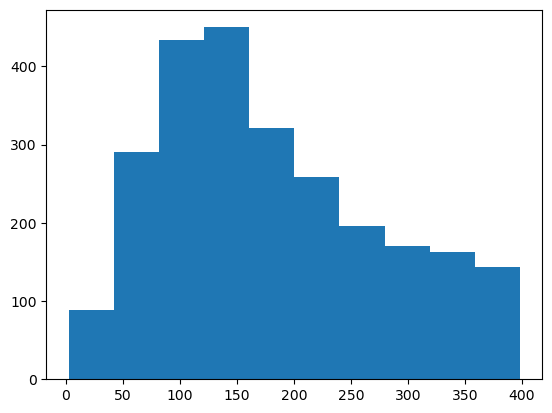

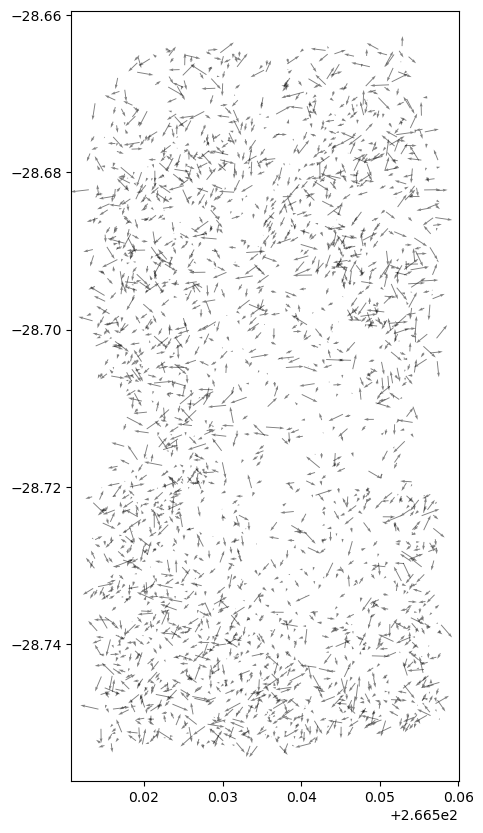

In [23]:
quiver(virac['skycoord'], crd6927, scale=0.0025, max_sep=0.4*u.arcsec)